In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:

# Image size
H, W = 4,4 # 8, 8

def show_image(img, title=None):
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])
    if title:
        plt.title(title)


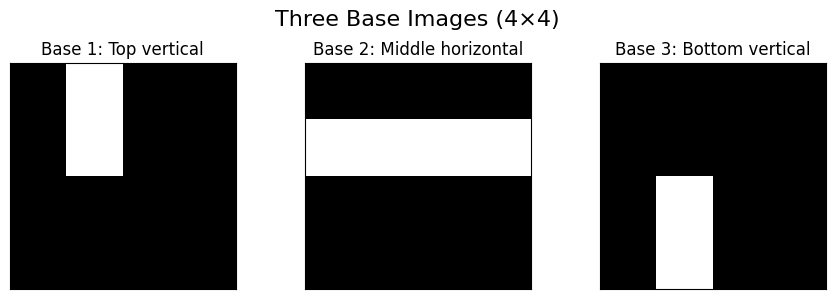

In [29]:
# --------------------------------------------------
# 1. Create 3 base images in 4x4 pixel space
# --------------------------------------------------

base_top_vertical = np.zeros((H, W))
base_middle_horizontal = np.zeros((H, W))
base_bottom_vertical = np.zeros((H, W))

# Top vertical line
base_top_vertical[0:2, 1] = 1

# Middle horizontal line
base_middle_horizontal[1, 0:4] = 1

# Bottom vertical line
base_bottom_vertical[2:4, 1] = 1

base_images = np.array([
    base_top_vertical,
    base_middle_horizontal,
    base_bottom_vertical
])

base_names = [
    "Base 1: Top vertical",
    "Base 2: Middle horizontal",
    "Base 3: Bottom vertical"
]

# Show base images
plt.figure(figsize=(9, 3))

for i, (img, name) in enumerate(zip(base_images, base_names)):
    plt.subplot(1, 3, i + 1)
    show_image(img, name)

plt.suptitle("Three Base Images (4×4)", fontsize=16)
plt.tight_layout()
plt.show()

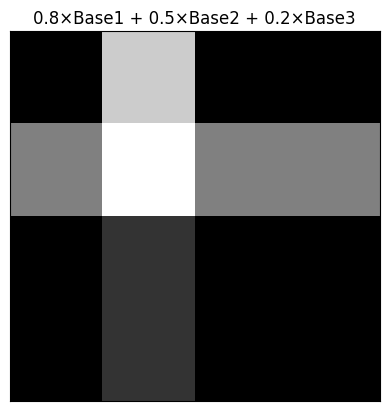

In [30]:
example = (
    0.8 * base_top_vertical +
    0.5 * base_middle_horizontal +
    0.2 * base_bottom_vertical
)

show_image(example, "0.8×Base1 + 0.5×Base2 + 0.2×Base3")

Generated images shape: (30, 4, 4)
Coefficients shape: (30, 3)


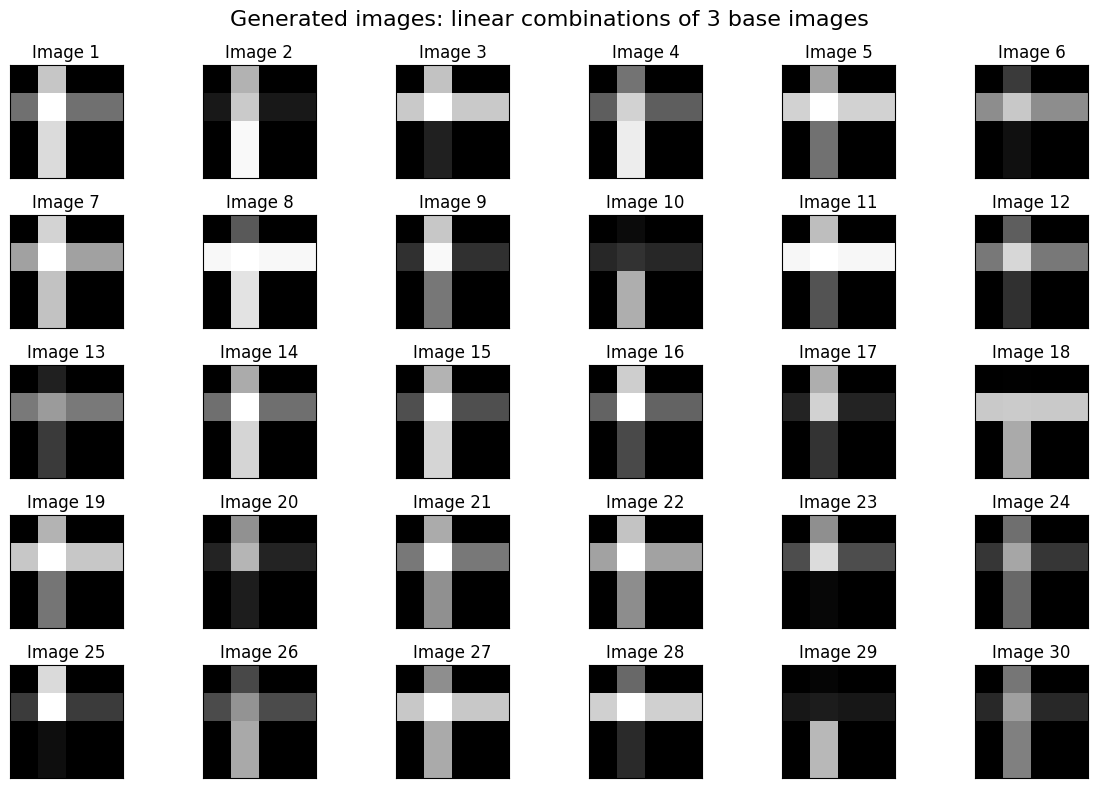

In [31]:


# --------------------------------------------------
# 2. Create random linear combinations
# --------------------------------------------------

rng = np.random.default_rng(42)

n_images = 30

# Each generated image gets 3 coefficients:
# how much of base 1, base 2, and base 3 it contains.
coefficients = rng.uniform(0, 1, size=(n_images, 3))

generated_images = []

for a, b, c in coefficients:
    img = (
        a * base_top_vertical
        + b * base_middle_horizontal
        + c * base_bottom_vertical
    )
    
    # Keep pixel values between 0 and 1 for easy display
    img = np.clip(img, 0, 1)
    generated_images.append(img)

generated_images = np.array(generated_images)

print("Generated images shape:", generated_images.shape)
print("Coefficients shape:", coefficients.shape)


# --------------------------------------------------
# 3. Show generated images
# --------------------------------------------------

plt.figure(figsize=(12, 8))

for i, img in enumerate(generated_images):
    plt.subplot(5, 6, i + 1)
    show_image(img, title=f"Image {i+1}")
    
plt.suptitle("Generated images: linear combinations of 3 base images", fontsize=16)
plt.tight_layout()
plt.show()

# PCA Story: Image → Vector → Point → New Coordinates → Reconstruction

We will use tiny 4×4 images.

Each image has:

$$ 4 \times 4 = 16 $$

pixels.

So each image can be represented as a vector with 16 numbers.

The important idea:

**Image = vector = point in a 16-dimensional space**

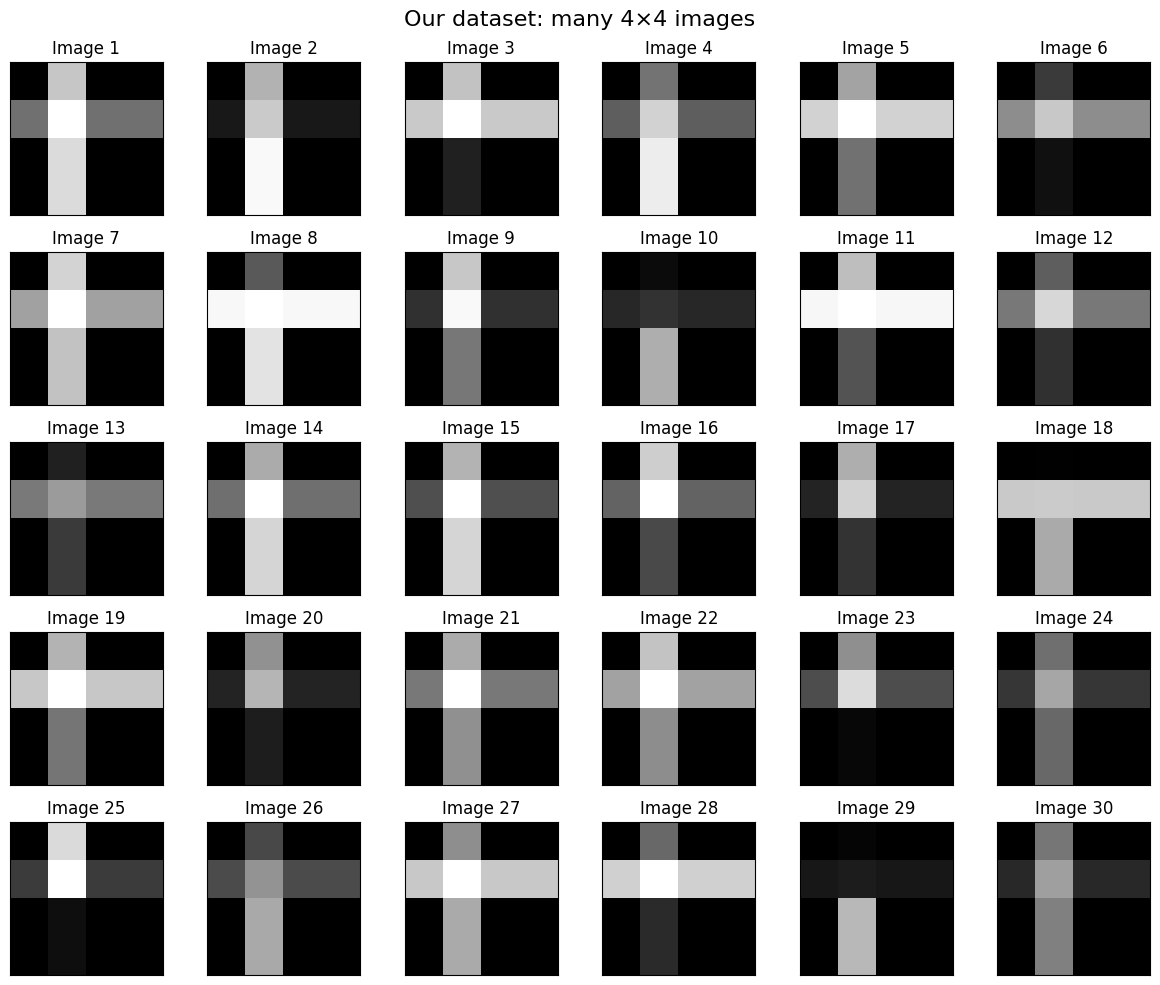

Dataset shape: (30, 4, 4)
Meaning: number of images, height, width


In [32]:
# --------------------------------------------------
# Part 1: Show the image dataset
# --------------------------------------------------

n_images = len(generated_images)

cols = 6
rows = int(np.ceil(n_images / cols))

plt.figure(figsize=(12, 2 * rows))

for i, img in enumerate(generated_images):
    plt.subplot(rows, cols, i + 1)
    show_image(img, title=f"Image {i+1}")

plt.suptitle("Our dataset: many 4×4 images", fontsize=16)
plt.tight_layout()
plt.show()

print("Dataset shape:", generated_images.shape)
print("Meaning: number of images, height, width")

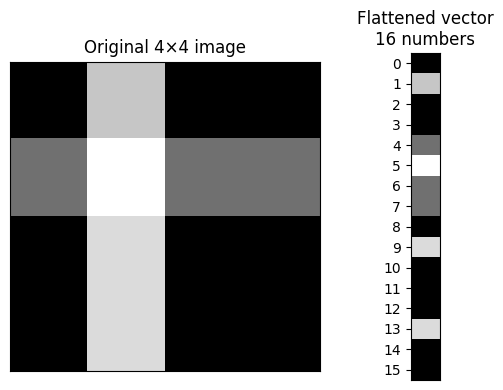

Original image shape: (4, 4)
Flattened vector shape: (16,)

Vector values:
[0.   0.77 0.   0.   0.44 1.   0.44 0.44 0.   0.86 0.   0.   0.   0.86
 0.   0.  ]


In [33]:
# --------------------------------------------------
# Part 2: Image -> Vector
# --------------------------------------------------

image_index = 0

img = generated_images[image_index]
vector = img.reshape(-1)

plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
show_image(img, title="Original 4×4 image")

plt.subplot(1, 2, 2)

plt.imshow(
    vector.reshape(-1, 1),
    cmap="gray",
    vmin=0,
    vmax=1,
    aspect=0.7   # make it much narrower
)

plt.xticks([])
plt.yticks(range(len(vector)))
plt.title("Flattened vector\n16 numbers")    
plt.tight_layout()
plt.show()

print("Original image shape:", img.shape)
print("Flattened vector shape:", vector.shape)
print()
print("Vector values:")
print(np.round(vector, 2))

In [34]:
X = generated_images.reshape(len(generated_images), -1)

print(X.shape)

(30, 16)


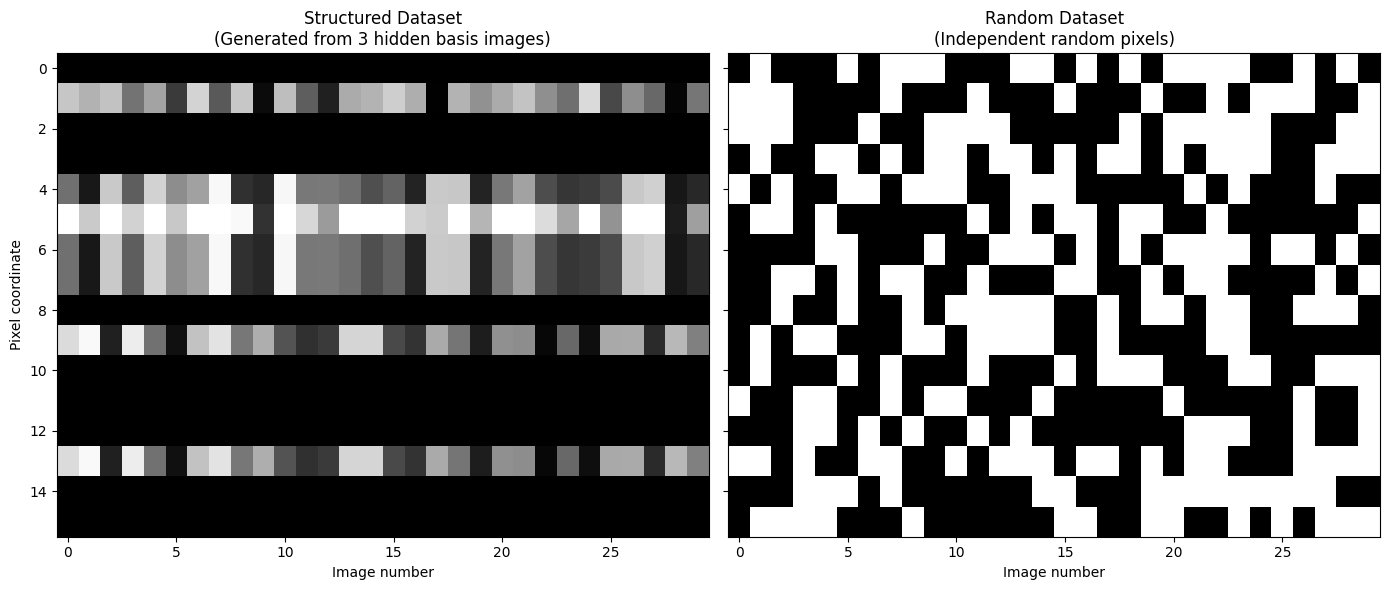

Both datasets have shape: (30, 16)

Left: strong correlation between pixels
Right: almost no correlation between pixels


In [35]:
# --------------------------------------------------
# Compare structured data vs random data
# --------------------------------------------------

# Structured dataset
X_structured = generated_images.reshape(len(generated_images), -1)

# Completely random dataset
rng = np.random.default_rng(123)

# X_random = rng.uniform(
#     low=0,
#     high=1,
#     size=X_structured.shape
# )

X_random = rng.integers(
    0,
    2,
    size=X_structured.shape
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True
)

# Structured
im1 = axes[0].imshow(
    X_structured.T,
    cmap="gray",
    aspect="auto",
    interpolation="nearest"
)

axes[0].set_title(
    "Structured Dataset\n(Generated from 3 hidden basis images)"
)
axes[0].set_xlabel("Image number")
axes[0].set_ylabel("Pixel coordinate")

# Random
im2 = axes[1].imshow(
    X_random.T,
    cmap="gray",
    aspect="auto",
    interpolation="nearest"
)

axes[1].set_title(
    "Random Dataset\n(Independent random pixels)"
)
axes[1].set_xlabel("Image number")

plt.tight_layout()
plt.show()

print("Both datasets have shape:", X_structured.shape)
print()
print("Left: strong correlation between pixels")
print("Right: almost no correlation between pixels")

In [36]:
# --------------------------------------------------
# Part 3: All images -> points in 16-dimensional space
# --------------------------------------------------

X = generated_images.reshape(n_images, -1)

print("X shape:", X.shape)
print()
print("Meaning:")
print(f"{X.shape[0]} images")
print(f"{X.shape[1]} pixels per image")
print()
print("So we now have:")
print(f"{X.shape[0]} points in {X.shape[1]}-dimensional space")

X shape: (30, 16)

Meaning:
30 images
16 pixels per image

So we now have:
30 points in 16-dimensional space


Original coordinates shape: (30, 16)
PCA coordinates shape: (30, 2)

Explained variance ratio:
[0.483 0.333]

Total variance explained by 2 PCA components:
0.815


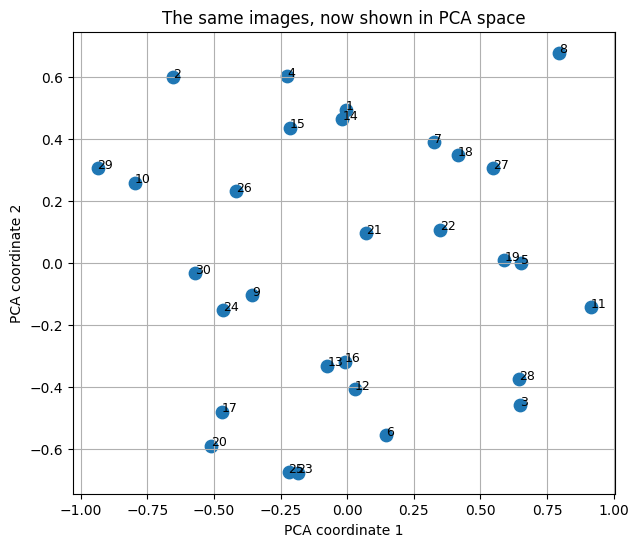

In [37]:
# --------------------------------------------------
# Part 4: PCA creates new coordinates
# --------------------------------------------------

from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

print("Original coordinates shape:", X.shape)
print("PCA coordinates shape:", X_pca_2d.shape)
print()
print("Explained variance ratio:")
print(np.round(pca_2d.explained_variance_ratio_, 3))
print()
print("Total variance explained by 2 PCA components:")
print(round(pca_2d.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(7, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=80)

for i in range(n_images):
    plt.text(X_pca_2d[i, 0], X_pca_2d[i, 1], str(i + 1), fontsize=9)

plt.xlabel("PCA coordinate 1")
plt.ylabel("PCA coordinate 2")
plt.title("The same images, now shown in PCA space")
plt.grid(True)
plt.show()

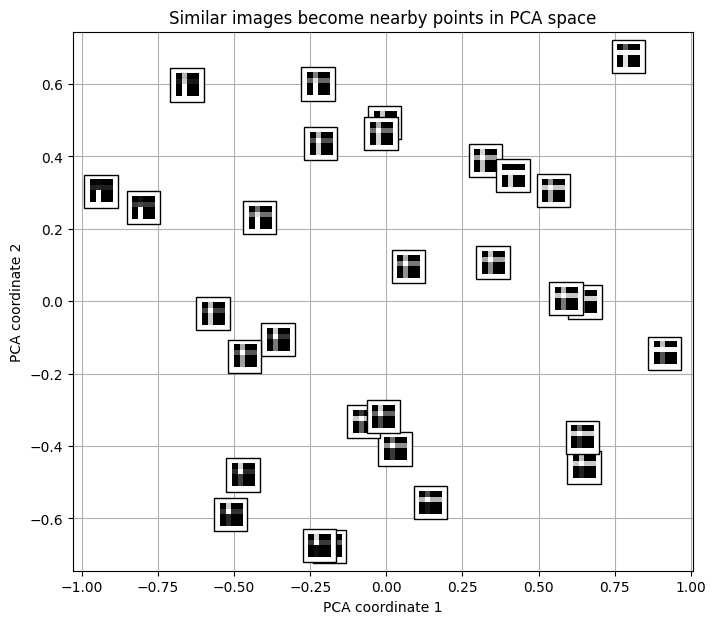

In [38]:
# --------------------------------------------------
# Part 5: Show image thumbnails inside PCA space
# --------------------------------------------------

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0)

for i, img in enumerate(generated_images):
    imagebox = OffsetImage(img, cmap="gray", zoom=4)
    ab = AnnotationBbox(
        imagebox,
        (X_pca_2d[i, 0], X_pca_2d[i, 1]),
        frameon=True
    )
    ax.add_artist(ab)

ax.set_xlabel("PCA coordinate 1")
ax.set_ylabel("PCA coordinate 2")
ax.set_title("Similar images become nearby points in PCA space")
ax.grid(True)

plt.show()

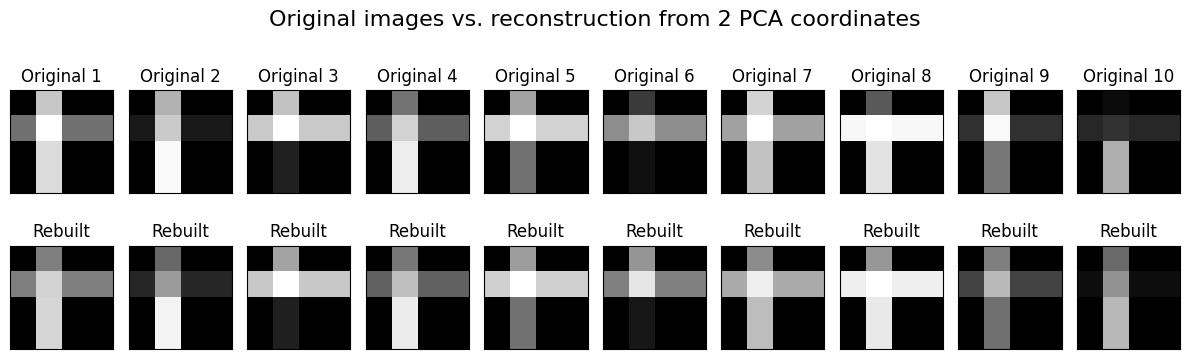

In [39]:
# --------------------------------------------------
# Part 6: Reconstruct images from only 2 PCA coordinates
# --------------------------------------------------

X_reconstructed = pca_2d.inverse_transform(X_pca_2d)
reconstructed_images = X_reconstructed.reshape(n_images, H, W)

n_show = min(10, n_images)

plt.figure(figsize=(12, 4))

for i in range(n_show):
    plt.subplot(2, n_show, i + 1)
    show_image(generated_images[i], title=f"Original {i+1}")

    plt.subplot(2, n_show, n_show + i + 1)
    show_image(reconstructed_images[i], title="Rebuilt")

plt.suptitle("Original images vs. reconstruction from 2 PCA coordinates", fontsize=16)
plt.tight_layout()
plt.show()

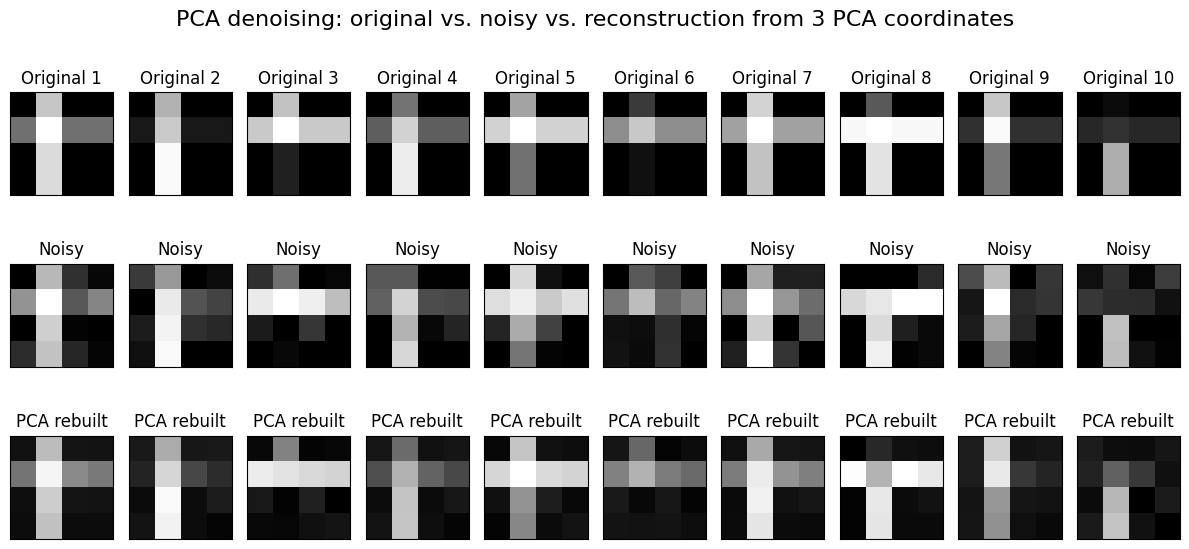

Noise level: 0.15
Explained variance ratio:
[0.379 0.253 0.173]

Total variance explained by 3 PCA components:
0.805


In [ ]:
# --------------------------------------------------
# Part 7: Add noise and use PCA reconstruction as denoising
# --------------------------------------------------

rng = np.random.default_rng(123)

noise_level = 0.15

# Flatten clean images
X_clean = generated_images.reshape(n_images, -1)

# Add random noise
X_noisy = X_clean + rng.normal(
    loc=0,
    scale=noise_level,# --------------------------------------------------
# Part 7: PCA Denoising Demo
# (independent of the earlier 4×4 PCA explanation)
# --------------------------------------------------

from sklearn.decomposition import PCA

# ==================================================
# Change this to 8, 16, 32 ...
# ==================================================

DEMO_SIZE = 8

# ==================================================
# Create higher-resolution basis images
# ==================================================

H_demo = DEMO_SIZE
W_demo = DEMO_SIZE

base_top_vertical = np.zeros((H_demo, W_demo))
base_middle_horizontal = np.zeros((H_demo, W_demo))
base_bottom_vertical = np.zeros((H_demo, W_demo))

center_col = W_demo // 2
center_row = H_demo // 2

# Top vertical
base_top_vertical[: H_demo // 2, center_col] = 1

# Middle horizontal
base_middle_horizontal[center_row, :] = 1

# Bottom vertical
base_bottom_vertical[H_demo // 2 :, center_col] = 1

# ==================================================
# Generate clean images
# ==================================================

rng = np.random.default_rng(123)

n_images = 100

coefficients = rng.uniform(
    0,
    1,
    size=(n_images, 3)
)

clean_images = []

for a, b, c in coefficients:

    img = (
        a * base_top_vertical
        + b * base_middle_horizontal
        + c * base_bottom_vertical
    )

    clean_images.append(img)

clean_images = np.array(clean_images)

# ==================================================
# Flatten
# ==================================================

X_clean = clean_images.reshape(n_images, -1)

# ==================================================
# Add noise
# ==================================================

noise_level = 0.15

X_noisy = X_clean + rng.normal(
    loc=0,
    scale=noise_level,
    size=X_clean.shape
)

X_noisy = np.clip(X_noisy, 0, 1)

# ==================================================
# PCA denoising
# ==================================================

pca_denoise = PCA(n_components=3)

X_noisy_pca = pca_denoise.fit_transform(X_noisy)

X_denoised = pca_denoise.inverse_transform(
    X_noisy_pca
)

X_denoised = np.clip(X_denoised, 0, 1)

# ==================================================
# Back to images
# ==================================================

noisy_images = X_noisy.reshape(
    n_images,
    H_demo,
    W_demo
)

denoised_images = X_denoised.reshape(
    n_images,
    H_demo,
    W_demo
)

# ==================================================
# Visual comparison
# ==================================================

n_show = 8

plt.figure(figsize=(14, 6))

for i in range(n_show):

    plt.subplot(3, n_show, i + 1)
    show_image(
        clean_images[i],
        title=f"Original {i+1}"
    )

    plt.subplot(3, n_show, n_show + i + 1)
    show_image(
        noisy_images[i],
        title="Noisy"
    )

    plt.subplot(3, n_show, 2 * n_show + i + 1)
    show_image(
        denoised_images[i],
        title="PCA rebuilt"
    )

plt.suptitle(
    f"PCA Denoising ({DEMO_SIZE}×{DEMO_SIZE} images)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ==================================================
# Statistics
# ==================================================

print("Image size:", DEMO_SIZE, "x", DEMO_SIZE)
print("Pixels per image:", DEMO_SIZE * DEMO_SIZE)
print("Noise level:", noise_level)

print("\nExplained variance ratio:")
print(
    np.round(
        pca_denoise.explained_variance_ratio_,
        3
    )
)

print(
    "\nTotal variance explained:",
    round(
        pca_denoise.explained_variance_ratio_.sum(),
        3
    )
)
    size=X_clean.shape
)

# Keep values in display range
X_noisy = np.clip(X_noisy, 0, 1)

noisy_images = X_noisy.reshape(n_images, H, W)

# Fit PCA on the noisy images
# We use 3 components because the clean images were created from 3 hidden base images
pca_denoise = PCA(n_components=3)

X_noisy_pca = pca_denoise.fit_transform(X_noisy)
X_denoised = pca_denoise.inverse_transform(X_noisy_pca)

# Keep reconstructed pixels in display range
X_denoised = np.clip(X_denoised, 0, 1)

denoised_images = X_denoised.reshape(n_images, H, W)

n_show = min(10, n_images)

plt.figure(figsize=(12, 6))

for i in range(n_show):
    # Original clean image
    plt.subplot(3, n_show, i + 1)
    show_image(generated_images[i], title=f"Original {i+1}")

    # Noisy image
    plt.subplot(3, n_show, n_show + i + 1)
    show_image(noisy_images[i], title="Noisy")

    # PCA reconstruction
    plt.subplot(3, n_show, 2 * n_show + i + 1)
    show_image(denoised_images[i], title="PCA rebuilt")

plt.suptitle(
    "PCA denoising: original vs. noisy vs. reconstruction from 3 PCA coordinates",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Noise level:", noise_level)
print("Explained variance ratio:")
print(np.round(pca_denoise.explained_variance_ratio_, 3))
print()
print("Total variance explained by 3 PCA components:")
print(round(pca_denoise.explained_variance_ratio_.sum(), 3))

PCA keeps the directions where many images vary together.

Random noise is spread across many pixel directions, so when we reconstruct using only a few PCA components, some of the noise disappears.

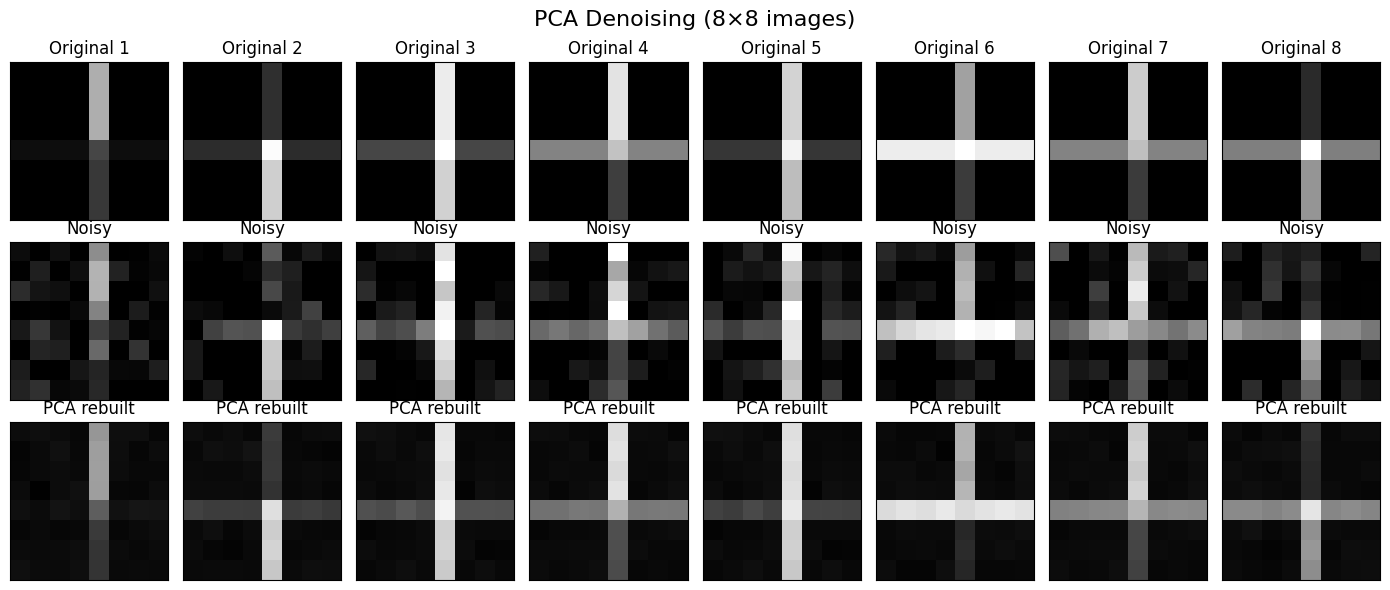

Image size: 8 x 8
Pixels per image: 64
Noise level: 0.1

Explained variance ratio:
[0.437 0.197 0.185]

Total variance explained: 0.819


In [ ]:
# --------------------------------------------------
# Part 7: PCA Denoising Demo
# (independent of the earlier 4×4 PCA explanation)
# --------------------------------------------------

from sklearn.decomposition import PCA

# ==================================================
# Change this to 8, 16, 32 ...
# ==================================================

DEMO_SIZE = 8

# ==================================================
# Create higher-resolution basis images
# ==================================================

H_demo = DEMO_SIZE
W_demo = DEMO_SIZE

base_top_vertical = np.zeros((H_demo, W_demo))
base_middle_horizontal = np.zeros((H_demo, W_demo))
base_bottom_vertical = np.zeros((H_demo, W_demo))

center_col = W_demo // 2
center_row = H_demo // 2

# Top vertical
base_top_vertical[: H_demo // 2, center_col] = 1

# Middle horizontal
base_middle_horizontal[center_row, :] = 1

# Bottom vertical
base_bottom_vertical[H_demo // 2 :, center_col] = 1

# ==================================================
# Generate clean images
# ==================================================

rng = np.random.default_rng(123)

n_images = 100

coefficients = rng.uniform(
    0,
    1,
    size=(n_images, 3)
)

clean_images = []

for a, b, c in coefficients:

    img = (
        a * base_top_vertical
        + b * base_middle_horizontal
        + c * base_bottom_vertical
    )

    clean_images.append(img)

clean_images = np.array(clean_images)

# ==================================================
# Flatten
# ==================================================

X_clean = clean_images.reshape(n_images, -1)

# ==================================================
# Add noise
# ==================================================

noise_level = 0.10

X_noisy = X_clean + rng.normal(
    loc=0,
    scale=noise_level,
    size=X_clean.shape
)

X_noisy = np.clip(X_noisy, 0, 1)

# ==================================================
# PCA denoising
# ==================================================

pca_denoise = PCA(n_components=3)

X_noisy_pca = pca_denoise.fit_transform(X_noisy)

X_denoised = pca_denoise.inverse_transform(
    X_noisy_pca
)

X_denoised = np.clip(X_denoised, 0, 1)

# ==================================================
# Back to images
# ==================================================

noisy_images = X_noisy.reshape(
    n_images,
    H_demo,
    W_demo
)

denoised_images = X_denoised.reshape(
    n_images,
    H_demo,
    W_demo
)

difference_images = np.abs(
    clean_images - denoised_images
)



# ==================================================
# Visual comparison
# ==================================================

n_show = 8

plt.figure(figsize=(14, 6))

for i in range(n_show):

    plt.subplot(4, n_show, i + 1)
    show_image(
        clean_images[i],
        title=f"Original {i+1}"
    )

    plt.subplot(3, n_show, n_show + i + 1)
    show_image(
        noisy_images[i],
        title="Noisy"
    )

    plt.subplot(3, n_show, 2 * n_show + i + 1)
    show_image(
        denoised_images[i],
        title="PCA rebuilt"
    )

    plt.subplot(4, n_show, 2 * n_show + i + 1)
    show_image(
        difference_images[i],
        title="Noise removed"
    )

plt.suptitle(
    f"PCA Denoising ({DEMO_SIZE}×{DEMO_SIZE} images)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ==================================================
# Statistics
# ==================================================

print("Image size:", DEMO_SIZE, "x", DEMO_SIZE)
print("Pixels per image:", DEMO_SIZE * DEMO_SIZE)
print("Noise level:", noise_level)

print("\nExplained variance ratio:")
print(
    np.round(
        pca_denoise.explained_variance_ratio_,
        3
    )
)

print(
    "\nTotal variance explained:",
    round(
        pca_denoise.explained_variance_ratio_.sum(),
        3
    )
)